In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import joblib as jb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("Churn_Data.csv.csv")
print(df)

      CustomerID  Gender  Age  Tenure       Balance  Products HasCreditCard  \
0     CUST100000       F   29      67  42290.135182         2             Y   
1     CUST100001    male   64      62   8572.456413         1             Y   
2     CUST100002       M   57     109  73354.838511         1            No   
3     CUST100003    male   53      39  34499.100740         3             N   
4     CUST100004    male   32      37  32910.130745         3             Y   
...          ...     ...  ...     ...           ...       ...           ...   
5045  CUST103906    male   54       1  26375.976537         1           Yes   
5046  CUST103773  female   46      26  39941.806999         2             Y   
5047  CUST104635  female   35      97  63587.627460         1             Y   
5048  CUST103161       M   32      80  68308.059410         2             Y   
5049  CUST102659  Female   23     115  72413.714128         3           Yes   

     IsActiveMember  EstimatedSalary Geography  Chu

In [5]:
df. head(5)

,CustomerID,Gender,Age,Tenure,Balance,Products,HasCreditCard,IsActiveMember,EstimatedSalary,Geography,Churn
0,CUST100000,F,29,67,42290.135182,2,Y,No,117422.959315,Nigeria,0
1,CUST100001,male,64,62,8572.456413,1,Y,No,69733.588343,Nigeria,1
2,CUST100002,M,57,109,73354.838511,1,No,Yes,105949.108279,Ghana,0
3,CUST100003,male,53,39,34499.100740,3,N,Yes,95555.653349,Nigeria,0
4,CUST100004,male,32,37,32910.130745,3,Y,Yes,54565.383506,Nigeria,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       5050 non-null   object 
 1   Gender           5050 non-null   object 
 2   Age              5050 non-null   int64  
 3   Tenure           5050 non-null   int64  
 4   Balance          4745 non-null   float64
 5   Products         5050 non-null   int64  
 6   HasCreditCard    5050 non-null   object 
 7   IsActiveMember   5050 non-null   object 
 8   EstimatedSalary  5050 non-null   float64
 9   Geography        5050 non-null   object 
 10  Churn            5050 non-null   int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 434.1+ KB


In [7]:
df.describe()

,Age,Tenure,Balance,Products,EstimatedSalary,Churn
count,5050.000000,5050.000000,4745.000000,5050.000000,5.050000e+03,5050.00000
mean,43.480594,59.954059,50023.717845,1.780792,1.098604e+05,0.20000
std,14.844427,33.980641,20039.381128,0.903585,1.081046e+05,0.40004
min,18.000000,1.000000,-28448.005032,1.000000,-5.870846e+04,0.00000
25%,31.000000,30.000000,36783.176065,1.000000,7.300407e+04,0.00000
50%,43.000000,61.000000,49963.424823,2.000000,1.008276e+05,0.00000
75%,56.000000,89.000000,63350.961607,2.000000,1.276786e+05,0.00000
max,69.000000,119.000000,117555.364826,4.000000,1.869504e+06,1.00000


In [8]:
df.isnull().sum()

CustomerID           0
Gender               0
Age                  0
Tenure               0
Balance            305
Products             0
HasCreditCard        0
IsActiveMember       0
EstimatedSalary      0
Geography            0
Churn                0
dtype: int64

In [9]:
df["Balance"].fillna(df["Balance"].mean(), inplace=True)
print("Missing values fixed!")
print(df.isnull().sum())

Missing values fixed!
CustomerID         0
Gender             0
Age                0
Tenure             0
Balance            0
Products           0
HasCreditCard      0
IsActiveMember     0
EstimatedSalary    0
Geography          0
Churn              0
dtype: int64


In [10]:
df["Gender"] = df["Gender"].str.strip().str.lower()
df["Gender"] = df["Gender"].replace({
    "f": "female",
    "m": "male"
})
print(df["Gender"].value_counts())

Gender
male      2562
female    2488
Name: count, dtype: int64


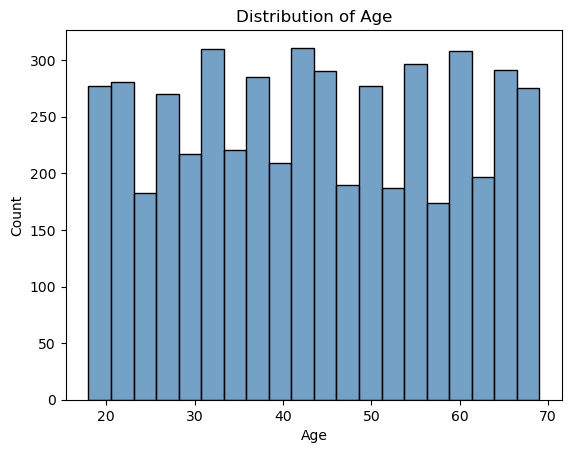

In [11]:
sns.histplot(df["Age"], bins=20, color="steelblue")

plt.title("Distribution of Age")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()



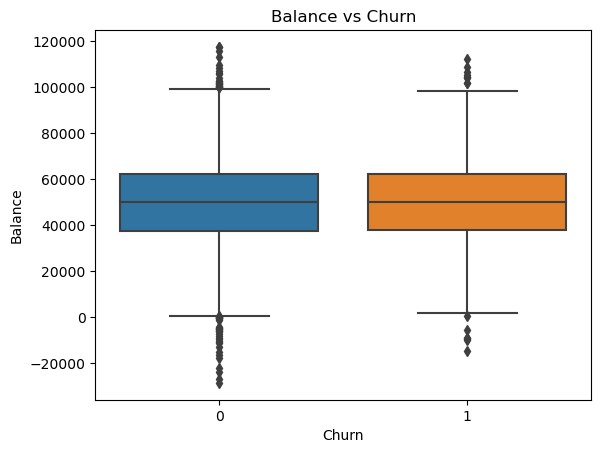

In [12]:
sns.boxplot(x="Churn", y="Balance", data=df)
plt.title("Balance vs Churn")
plt.show()



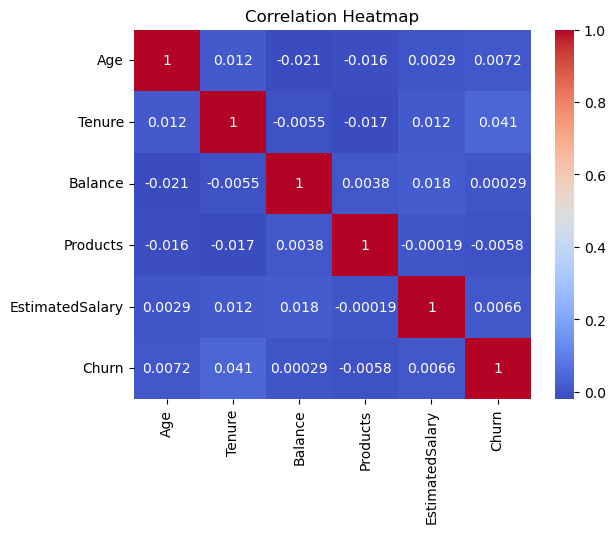

In [13]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [14]:
le = LabelEncoder()
df["Gender"] = le.fit_transform(df["Gender"])
df["HasCreditCard"] = le.fit_transform(df["HasCreditCard"])
df["IsActiveMember"] = le.fit_transform(df["IsActiveMember"])
df["Geography"] = le.fit_transform(df["Geography"])
print("Encoding done!")
print(df.head())

Encoding done!
   CustomerID  Gender  Age  Tenure       Balance  Products  HasCreditCard  \
0  CUST100000       0   29      67  42290.135182         2              2   
1  CUST100001       1   64      62   8572.456413         1              2   
2  CUST100002       1   57     109  73354.838511         1              1   
3  CUST100003       1   53      39  34499.100740         3              0   
4  CUST100004       1   32      37  32910.130745         3              2   

   IsActiveMember  EstimatedSalary  Geography  Churn  
0               0    117422.959315          2      0  
1               0     69733.588343          2      1  
2               1    105949.108279          0      0  
3               1     95555.653349          2      0  
4               1     54565.383506          2      1  


In [15]:
X = df.drop(["Churn", "CustomerID"], axis=1)
y = df["Churn"]
print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['Gender', 'Age', 'Tenure', 'Balance', 'Products', 'HasCreditCard', 'IsActiveMember', 'EstimatedSalary', 'Geography']
Target: Churn


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (4040, 9)
Testing size: (1010, 9)


In [17]:
model = RandomForestClassifier(random_state=42)

In [18]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [19]:
predictions = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 82.08%


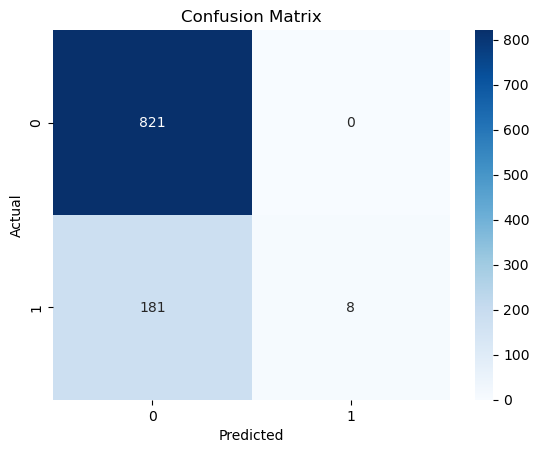

In [21]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90       821
           1       1.00      0.04      0.08       189

    accuracy                           0.82      1010
   macro avg       0.91      0.52      0.49      1010
weighted avg       0.85      0.82      0.75      1010



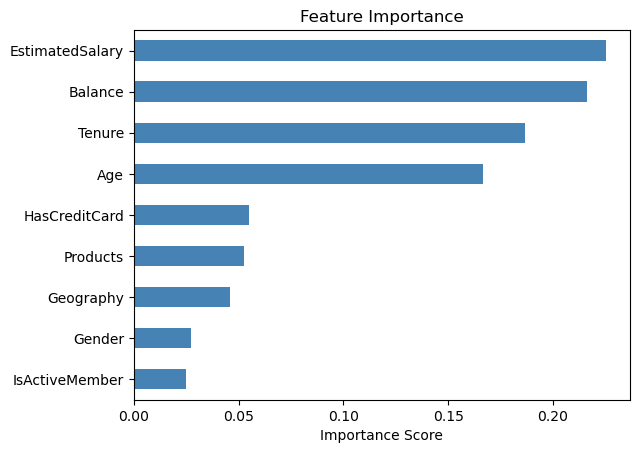

In [23]:
importance = model.feature_importances_
feature_importance = pd.Series(importance, index=X.columns)
feature_importance.sort_values().plot(kind="barh", color="steelblue")
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

In [24]:
# New customer data
# Age, Tenure, Balance, Products, HasCreditCard, 
# IsActiveMember, EstimatedSalary, Gender, Geography
new_customer = [[35, 5, 50000, 2, 1, 1, 80000, 1, 1]]
prediction = model.predict(new_customer)
if prediction[0] == 1:
    print("This customer is likely to CHURN!")
else:
    print("This customer is likely to STAY!")

This customer is likely to STAY!


C:\Users\user\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [25]:
import joblib
joblib.dump(model, "churn_model.joblib")

['churn_model.joblib']

In [26]:
# Capstone Project - Train Two Models
from sklearn.tree import DecisionTreeClassifier

# Model 1 - Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_predictions)

# Model 2 - Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")
print(f"Decision Tree Accuracy: {dt_accuracy:.2%}")

Random Forest Accuracy: 82.08%
Decision Tree Accuracy: 70.30%


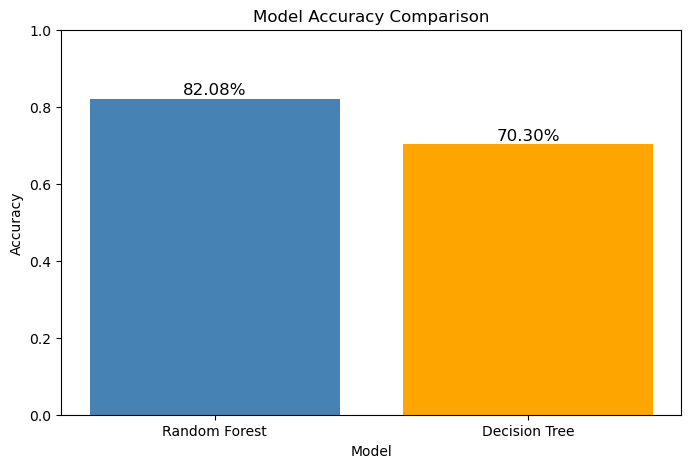

In [27]:
models = ["Random Forest", "Decision Tree"]
accuracies = [rf_accuracy, dt_accuracy]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=["steelblue", "orange"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.01, f"{acc:.2%}", 
             ha="center", fontsize=12)
plt.show()

In [28]:
if rf_accuracy > dt_accuracy:
    best_model = "Random Forest"
    best_accuracy = rf_accuracy
else:
    best_model = "Decision Tree"
    best_accuracy = dt_accuracy

print(f"Best Model: {best_model}")
print(f"Best Accuracy: {best_accuracy:.2%}")
print(f"\nConclusion: {best_model} is the best model")
print(f"for predicting customer churn with {best_accuracy:.2%} accuracy!")

Best Model: Random Forest
Best Accuracy: 82.08%

Conclusion: Random Forest is the best model
for predicting customer churn with 82.08% accuracy!


In [29]:
if best_model == "Random Forest":
    print(classification_report(y_test, rf_predictions))
else:
    print(classification_report(y_test, dt_predictions))

              precision    recall  f1-score   support

           0       0.82      1.00      0.90       821
           1       1.00      0.04      0.08       189

    accuracy                           0.82      1010
   macro avg       0.91      0.52      0.49      1010
weighted avg       0.85      0.82      0.75      1010



In [30]:
import joblib
if best_model == "Random Forest":
    joblib.dump(rf_model, "best_churn_model.joblib")
else:
    joblib.dump(dt_model, "best_churn_model.joblib")
    
print(f"{best_model} saved as best_churn_model.joblib!")

Random Forest saved as best_churn_model.joblib!


In [ ]:
Z